# Notebook 06 — Tracking con KymoButler sobre el dataset sintético real-scale

**Baseline de tracking** sobre los quimógrafos sintéticos calibrados en `datasets/{train,val,test}/`
(generados por `ingenia-kymograph`/`synthkymo` a partir de los 8 perfiles de
`../ingenia-kymograph/examples/dataset_profiles/` — ver `docs/handover.md` y
`docs/regenerar-dataset-sintetico.md`). Usamos **KymoButler** (Jakobs, Franze & Bhatt, _eLife_ 2019)
como baseline clásico: no se entrena nada, corre directo sobre el quimógrafo.

**Este notebook ya no depende del notebook 05** (que generaba un dataset de juguete con un único
generador simple — se mantiene en `05_kimografo.ipynb` para referencia histórica, pero no alimenta
este flujo). El dataset ahora viene de `scripts/generar_dataset_sintetico.py`, calibrado contra los
quimógrafos reales del laboratorio, y es el mismo `datasets/test/` que usa
`09_segmentacion_transformer.ipynb` para evaluar YOLO+SAM3 — así los números quedan comparables.

## Convenciones (sin cambios respecto a la versión anterior)

1. **Formato de entrada**: quimógrafo `.tif` (uint8) + `positions.csv` con `pos_um`.
2. **Conversión de GT**: `pos_um` → columna de quimógrafo con el flip de soma: `col = kymo_width - 1 - pos_um / pixel_scale`.
3. **Dirección en quimógrafo (convención flipped)**:
   - `anterograde` (pos_um creciente) → estela hacia la **izquierda** (col decreciente) → dirección predicha **-1**.
   - `retrograde` (pos_um decreciente) → estela hacia la **derecha** (col creciente) → dirección predicha **+1**.
   - `bidirectional` no tiene una dirección fija — se excluye de la métrica de acierto de dirección.
4. **Posible redimensionado de KymoButler**: si el ancho del quimógrafo no es múltiplo de 16, KymoButler
   puede redimensionar internamente. Se detecta comparando `raw.shape` con el TIFF nativo y se aplica
   un `scale_factor` a las coordenadas de los tracks antes de compararlos con el GT.

## Flujo

`datasets/test/sample_*/kymograph.tif` → PNG → KymoButler → `scale_factor` → comparación contra GT
(`positions.csv`). Primero un ejemplo detallado sobre una muestra, después métricas agregadas sobre
varias muestras de cada perfil.


---

## 0. Prerrequisitos

```bash
uv sync                            # instala kymobutler + synthkymo
cd ../KymoButler && git lfs pull   # baja pesos ONNX
```

El dataset en `datasets/{train,val,test}/` debe existir de antemano (este notebook no lo genera):

```bash
uv run python scripts/generar_dataset_sintetico.py   # corrida completa (100/50/50 por perfil)
```

Si `datasets/` no existe, está desactualizado, o hace falta regenerarlo, ver
`docs/regenerar-dataset-sintetico.md`.


---

## 1. Setup


In [1]:
import sys, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tifffile
import yaml
from PIL import Image

sys.path.append(str(Path("..") / "src"))

try:
    import kymobutler
except ImportError as exc:
    raise ImportError(
        "No se pudo importar kymobutler. Corre 'uv sync' en el repo."
    ) from exc

KYMOBUTLER_DIR = Path(kymobutler.__file__).resolve().parents[2]
MODELOS_DIR = KYMOBUTLER_DIR / "models"

# Dataset real-scale generado por scripts/generar_dataset_sintetico.py (ya no por NB05).
# pixel_scale_um/fps se leen del config.yaml de cada muestra (ver cargar_sample en la sección 3),
# no de axonal_tracking.parametros — ese módulo describe las sesiones de video reales, no el
# generador sintético.
DATASETS_DIR = Path("..") / "datasets"
SPLIT = "test"  # mismo split que usa 09_segmentacion_transformer.ipynb para evaluar
SPLIT_DIR = DATASETS_DIR / SPLIT
assert SPLIT_DIR.exists(), (
    f"Directorio no encontrado: {SPLIT_DIR}. Corre "
    f"'uv run python scripts/generar_dataset_sintetico.py' primero "
    f"(ver docs/regenerar-dataset-sintetico.md)."
)

# Verificar pesos
pesos_faltantes = [
    f
    for f in ("bidirectional_seg.onnx", "decision_module.onnx")
    if not (MODELOS_DIR / f).exists() or (MODELOS_DIR / f).stat().st_size < 1024
]
assert not pesos_faltantes, (
    f"Pesos faltantes o como puntero LFS: {pesos_faltantes}. "
    f"Corre en {KYMOBUTLER_DIR}: git lfs pull"
)

DEVICE = "cpu"

print(f"KymoButler : {KYMOBUTLER_DIR}")
print(f"Dataset    : {SPLIT_DIR.resolve()}")
print("Setup OK.")

KymoButler : /Users/alejandrovalle/Desktop/Posgrado/CEIA/KymoButler
Dataset    : /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/test
Setup OK.


---

## 2. Cargar modelos


In [2]:
from kymobutler.models.weights import load_default_models

models = load_default_models(model_dir=MODELOS_DIR, device=DEVICE)
print("Modelos cargados:", list(models.keys()))

Modelos cargados: ['binet', 'uninet', 'decnet', 'classnet']


### Smoke test (bitest.png de KymoButler)


In [3]:
from kymobutler.segmentation import segment_bidirectional
from kymobutler.tracking import track_bidirectional

_bitest = KYMOBUTLER_DIR / "tests" / "data" / "bitest.png"
if _bitest.exists():
    _wn, _raw, _pre, _pred = segment_bidirectional(
        str(_bitest), models["binet"], device=DEVICE
    )
    _tracks = track_bidirectional(
        _pred,
        _pre,
        _wn,
        vision_net=models["decnet"],
        threshold=0.2,
        min_size=10,
        min_frames=10,
        device=DEVICE,
    )
    print(f"Smoke test bitest.png: {len(_tracks)} tracks (esperado ~13)")
else:
    print("bitest.png no encontrado, salteo smoke test.")

/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]



Building tracks:   0%|          | 0/14 [00:00<?, ?it/s]


Building tracks:  21%|██▏       | 3/14 [00:00<00:00, 19.67it/s]


Building tracks:  50%|█████     | 7/14 [00:00<00:00, 29.07it/s]


Building tracks:  79%|███████▊  | 11/14 [00:00<00:00, 28.13it/s]

Smoke test bitest.png: 13 tracks (esperado ~13)


---

## 3. Funciones auxiliares

La versión anterior de este notebook procesaba una sola muestra "a mano". Acá queda como
funciones reutilizables, para poder correr el mismo pipeline tanto sobre una muestra en detalle
(secciones 4–9) como sobre varias muestras del dataset (sección 10).


In [4]:
GT_DIR = {
    "anterograde": -1,
    "pure_anterograde": -1,
    "retrograde": 1,
    "pure_retrograde": 1,
    "static": 0,
    "bidirectional": None,  # sin dirección fija -> se excluye de la métrica de dirección
}


def cargar_sample(sample_dir: Path):
    """Carga kymograph.tif/png, positions.csv, config.yaml y metadata.json de una muestra."""
    kymo_tif = sample_dir / "kymograph.tif"
    kymo_png = sample_dir / "kymograph.png"
    kymo_native = tifffile.imread(kymo_tif)
    if not kymo_png.exists():
        Image.fromarray(kymo_native, mode="L").save(kymo_png)

    config = yaml.safe_load((sample_dir / "config.yaml").read_text())
    meta = json.loads((sample_dir / "metadata.json").read_text())
    positions = pd.read_csv(sample_dir / "positions.csv")

    pixel_scale = config["general"]["pixel_scale_um"]
    fps = config["general"]["fps"]
    return kymo_native, kymo_png, positions, meta, pixel_scale, fps


def segmentar(kymo_png: Path, kymo_native_shape, models, device=DEVICE):
    """BiNet de KymoButler. scale_factor > 1 si KymoButler agrandó el quimógrafo, < 1 si achicó."""
    was_negated, raw, preprocessed, prediction = segment_bidirectional(
        str(kymo_png), models["binet"], device=device
    )
    scale_factor = raw.shape[1] / kymo_native_shape[1]
    return was_negated, raw, preprocessed, prediction, scale_factor


def trackear(prediction, preprocessed, was_negated, models, device=DEVICE):
    return track_bidirectional(
        prediction,
        preprocessed,
        was_negated,
        vision_net=models["decnet"],
        threshold=0.2,
        min_size=10,
        min_frames=10,
        device=device,
    )


def direccion_por_desplazamiento(points):
    """-1 columna decrece (anterógrado), +1 columna crece (retrógrado), 0 sin desplazamiento neto."""
    d = points[-1][1] - points[0][1]
    return int(np.sign(d)) if abs(d) > 1 else 0


def convertir_gt(
    positions: pd.DataFrame, kymo_native_w: int, pixel_scale: float, scale_factor: float
):
    """pos_um (distancia al soma) -> columna de quimógrafo con el flip de soma, escalada al espacio de KymoButler."""
    pos_vis = positions[positions.visible == 1].copy()
    pos_vis["kymo_col"] = (
        kymo_native_w - 1 - pos_vis["pos_um"] / pixel_scale
    ) * scale_factor

    tipo_de = dict(
        pos_vis.drop_duplicates("particle_id").set_index("particle_id")["type"]
    )
    gt_ids = sorted(tipo_de.keys())
    gt_dir = {pid: GT_DIR.get(tipo_de[pid]) for pid in gt_ids}

    gt_col = {
        (int(r.particle_id), int(r.frame)): float(r.kymo_col)
        for r in pos_vis.itertuples(index=False)
    }
    gt_por_frame = {
        int(f): list(zip(sub.particle_id, sub.kymo_col))
        for f, sub in pos_vis.groupby("frame")
    }
    return pos_vis, tipo_de, gt_ids, gt_dir, gt_col, gt_por_frame


def comparar_tracks(
    tracks,
    gt_por_frame,
    gt_col,
    tipo_de,
    gt_dir,
    scale_factor,
    pixel_scale,
    thr_px_nativo=4.0,
    min_overlap=10,
):
    """Asocia cada track predicho al GT más cercano por mayoría de frames dentro de thr_px."""
    thr_px = thr_px_nativo * scale_factor

    def gt_mas_cercano(t, x):
        mejor, dmin = -1, thr_px
        for pid, gx in gt_por_frame.get(int(t), []):
            d = abs(x - gx)
            if d <= dmin:
                mejor, dmin = int(pid), d
        return mejor

    filas = []
    for k, trk in enumerate(tracks):
        etiquetas = [gt_mas_cercano(t, x) for (t, x) in trk.points]
        conteo = Counter(l for l in etiquetas if l != -1)
        sustanciales = {pid: c for pid, c in conteo.items() if c >= min_overlap}
        dominante = (
            max(sustanciales, key=sustanciales.get)
            if sustanciales
            else (conteo.most_common(1)[0][0] if conteo else -1)
        )

        errs = [
            abs(x - gt_col[(dominante, int(t))])
            for (t, x), l in zip(trk.points, etiquetas)
            if l == dominante and dominante != -1 and (dominante, int(t)) in gt_col
        ]

        dir_pred = direccion_por_desplazamiento(trk.points)
        gt_d = gt_dir.get(dominante)
        dir_ok = np.nan if (dominante == -1 or gt_d is None) else (dir_pred == gt_d)

        filas.append(
            {
                "track": k,
                "gt_id": dominante,
                "gt_tipo": tipo_de.get(dominante, "-"),
                "n_puntos": len(trk.points),
                "id_switch": len(sustanciales) > 1,
                "dir_pred": dir_pred,
                "dir_gt": gt_d,
                "dir_ok": dir_ok,
                "err_px": float(np.mean(errs)) if errs else np.nan,
                "err_um": (
                    float(np.mean(errs)) / scale_factor * pixel_scale
                    if errs
                    else np.nan
                ),
            }
        )
    return pd.DataFrame(filas)


def resumen_metricas(
    comp: pd.DataFrame, gt_ids, tipo_de, tracks, scale_factor, pixel_scale
):
    """Recall, error de posición, acierto de dirección e ID-switches, resumidos en un dict."""
    asociados = comp[comp.gt_id != -1]
    recuperadas = set(asociados.gt_id)

    recall_por_tipo = {}
    for tipo in ("static", "anterograde", "retrograde", "bidirectional"):
        ids_tipo = [p for p in gt_ids if tipo_de.get(p) == tipo]
        if not ids_tipo:
            continue
        rec = len([p for p in ids_tipo if p in recuperadas])
        recall_por_tipo[tipo] = (rec, len(ids_tipo))

    err_validos = asociados.err_px.dropna()
    err_native_px = err_validos / scale_factor if len(err_validos) else err_validos
    dir_validos = asociados.dir_ok.dropna()

    return {
        "n_gt": len(gt_ids),
        "n_recuperadas": len(recuperadas),
        "recall_global": len(recuperadas) / len(gt_ids) if gt_ids else np.nan,
        "recall_por_tipo": recall_por_tipo,
        "err_medio_px": float(err_native_px.mean()) if len(err_native_px) else np.nan,
        "err_medio_um": (
            float((err_native_px * pixel_scale).mean())
            if len(err_native_px)
            else np.nan
        ),
        "dir_accuracy": float(dir_validos.mean()) if len(dir_validos) else np.nan,
        "n_dir_evaluados": int(len(dir_validos)),
        "n_idswitch": int(comp.id_switch.sum()),
        "n_tracks": len(tracks),
        "n_falsos_positivos": int((comp.gt_id == -1).sum()),
    }

---

## 4. Selección de muestra

`datasets/test/` tiene una muestra por cada uno de los 8 perfiles calibrados de
`../ingenia-kymograph/examples/dataset_profiles/`, escritas en orden por
`scripts/generar_dataset_sintetico.py` (no queda registrado en `metadata.json`, así que el perfil
de cada fila se deriva de su posición en el manifest). Para el recorrido detallado usamos la
primera muestra del perfil `wt_n1` (wild-type, nivel de ruido 1 — el más "limpio" de los 8).


In [5]:
df_manifest = pd.read_csv(SPLIT_DIR / "manifest.csv")

# scripts/generar_dataset_sintetico.py escribe, en este orden, N muestras consecutivas por perfil.
PROFILES = [
    "wt_n1",
    "wt_n2",
    "wt_n3",
    "lbd_n1",
    "lbd_n2",
    "lbd_n3",
    "mixed_i3_crowded",
    "static_dominant_edge",
]
N_POR_PERFIL_TEST = len(df_manifest) // len(PROFILES)
assert len(df_manifest) == len(PROFILES) * N_POR_PERFIL_TEST, (
    "manifest.csv no tiene un múltiplo exacto de len(PROFILES) filas -- el dataset fue "
    "regenerado con otros perfiles/tamaños, hay que revisar PROFILES."
)
df_manifest["profile"] = [
    PROFILES[i // N_POR_PERFIL_TEST] for i in df_manifest["index"]
]

print(
    f"{len(df_manifest)} muestras en el split '{SPLIT}', {N_POR_PERFIL_TEST} por perfil.\n"
)
print(
    df_manifest.groupby("profile")[["n_particles", "n_frames", "kymograph_width"]]
    .mean()
    .round(1)
)

SAMPLE = df_manifest[df_manifest.profile == "wt_n1"].iloc[0]["sample_dir"]
SAMPLE_DIR = SPLIT_DIR / SAMPLE
print(f"\nMuestra de ejemplo: {SAMPLE} (perfil wt_n1)")

400 muestras en el split 'test', 50 por perfil.

                      n_particles  n_frames  kymograph_width
profile                                                     
lbd_n1                       20.0      99.7           1338.9
lbd_n2                       26.0     296.5           1302.3
lbd_n3                       44.0     386.8           1335.6
mixed_i3_crowded             30.0      61.6           1302.8
static_dominant_edge         30.0     316.6           1202.0
wt_n1                        24.0     194.0           1257.7
wt_n2                        23.0     214.2           1295.0
wt_n3                        23.0     182.6           1281.5

Muestra de ejemplo: sample_00000 (perfil wt_n1)


In [6]:
kymo_native, KYMO_PNG, positions, meta, PIXEL_SCALE, FPS = cargar_sample(SAMPLE_DIR)
kymo_native_h, kymo_native_w = kymo_native.shape

print(f"kymo nativo  : {kymo_native_h} × {kymo_native_w} px  (frames × pos_axon)")
print(f"kymo_w / 16  : {kymo_native_w / 16:.2f}")
print(f"pixel_scale  : {PIXEL_SCALE} µm/px")
print(f"fps          : {FPS}")
print(f"Metadata     : {meta}")

kymo nativo  : 170 × 979 px  (frames × pos_axon)
kymo_w / 16  : 61.19
pixel_scale  : 0.107 µm/px
fps          : 3.29
Metadata     : {'nucleus_position': 'bottom', 'soma_xy': [493.2557697084989, 1145.0], 'distal_xy': [1276.0, 618.4793740937059], 'axon_length_um': 104.77003045035622, 'seed': 1014000}


---

## 5. Segmentación con KymoButler

Comparamos `raw.shape` con el tamaño nativo del TIFF para detectar si KymoButler redimensionó. Si
hay diferencia, `scale_factor` traduce coordenadas de track ↔ GT.


/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]


was_negated  = False  (False = fondo oscuro, correcto para quimógrafo con tubo brillante)
raw.shape    = (170, 979)
kymo nativo  = (170, 979)
scale_factor = 1.0000  (sin redimensionado)


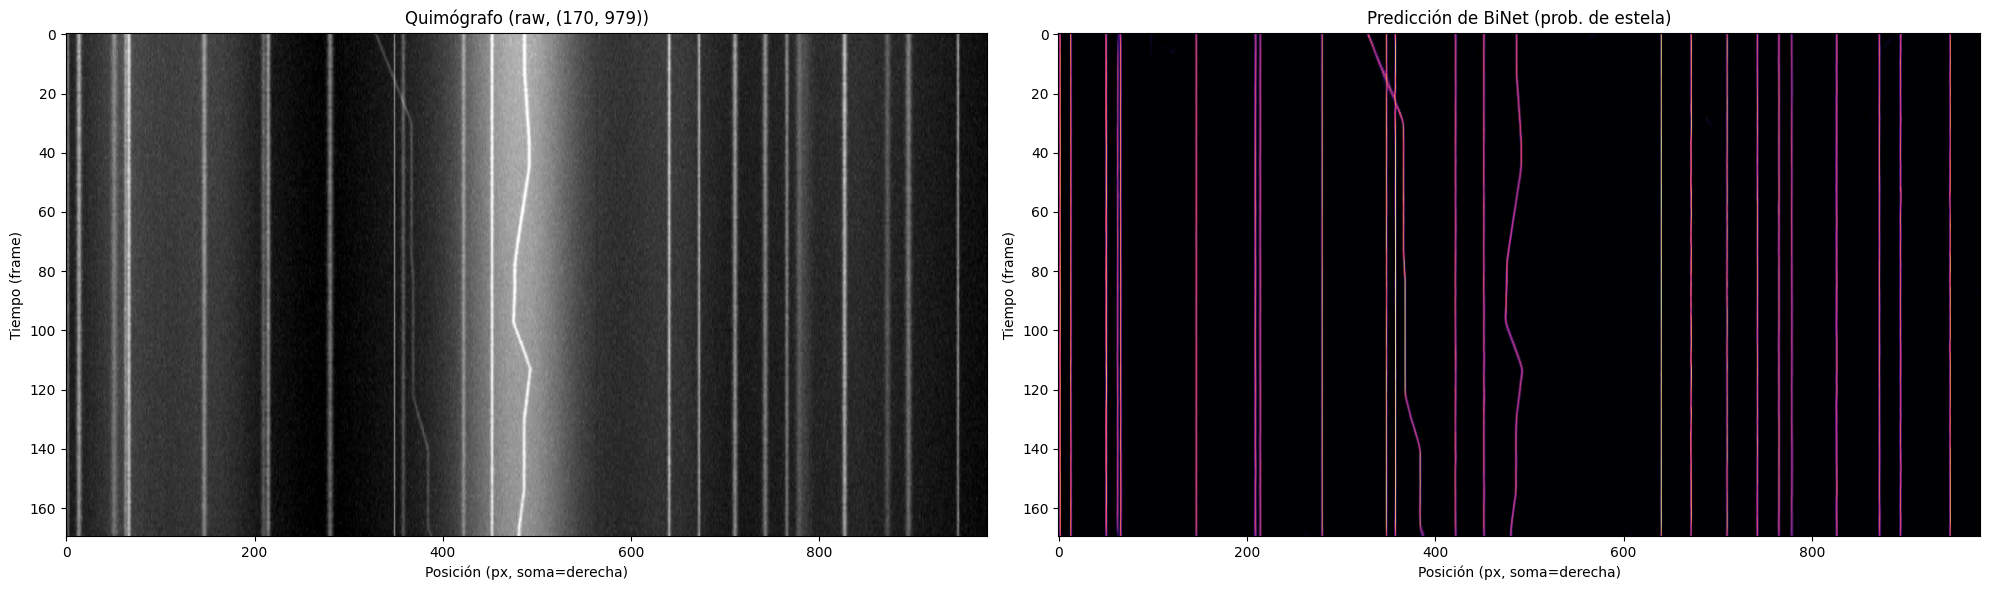

In [7]:
was_negated, raw, preprocessed, prediction, scale_factor = segmentar(
    KYMO_PNG, kymo_native.shape, models
)

print(
    f"was_negated  = {was_negated}  (False = fondo oscuro, correcto para quimógrafo con tubo brillante)"
)
print(f"raw.shape    = {raw.shape}")
print(f"kymo nativo  = {kymo_native.shape}")
print(
    f"scale_factor = {scale_factor:.4f}  ({'sin redimensionado' if abs(scale_factor-1)<0.01 else '⚠ KymoButler redimensionó — se aplica escala'})",
)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
axes[0].imshow(raw, cmap="gray", aspect="auto")
axes[0].set_title(f"Quimógrafo (raw, {raw.shape})")
axes[1].imshow(prediction, cmap="magma", aspect="auto")
axes[1].set_title("Predicción de BiNet (prob. de estela)")
for ax in axes:
    ax.set_xlabel("Posición (px, soma=derecha)")
    ax.set_ylabel("Tiempo (frame)")
plt.tight_layout()
plt.show()

---

## 6. Tracking


In [8]:
tracks = trackear(prediction, preprocessed, was_negated, models)
print(f"Tracks detectados: {len(tracks)}")
if tracks:
    largos = [len(t.points) for t in tracks]
    print(
        f"  Puntos/track: min={min(largos)}, mediana={int(np.median(largos))}, max={max(largos)}"
    )


Building tracks:   0%|          | 0/25 [00:00<?, ?it/s]


Building tracks:  36%|███▌      | 9/25 [00:00<00:00, 86.92it/s]


Building tracks:  76%|███████▌  | 19/25 [00:00<00:00, 92.92it/s]

Tracks detectados: 25
  Puntos/track: min=160, mediana=163, max=166


### Overlay de tracks

Convención de colores **según dirección en el quimógrafo** (flip: soma=derecha):

- **Magenta** = columna decrece → anterógrado (se aleja del soma).
- **Cyan** = columna crece → retrógrado (se acerca al soma).
- **Amarillo** = sin desplazamiento neto.


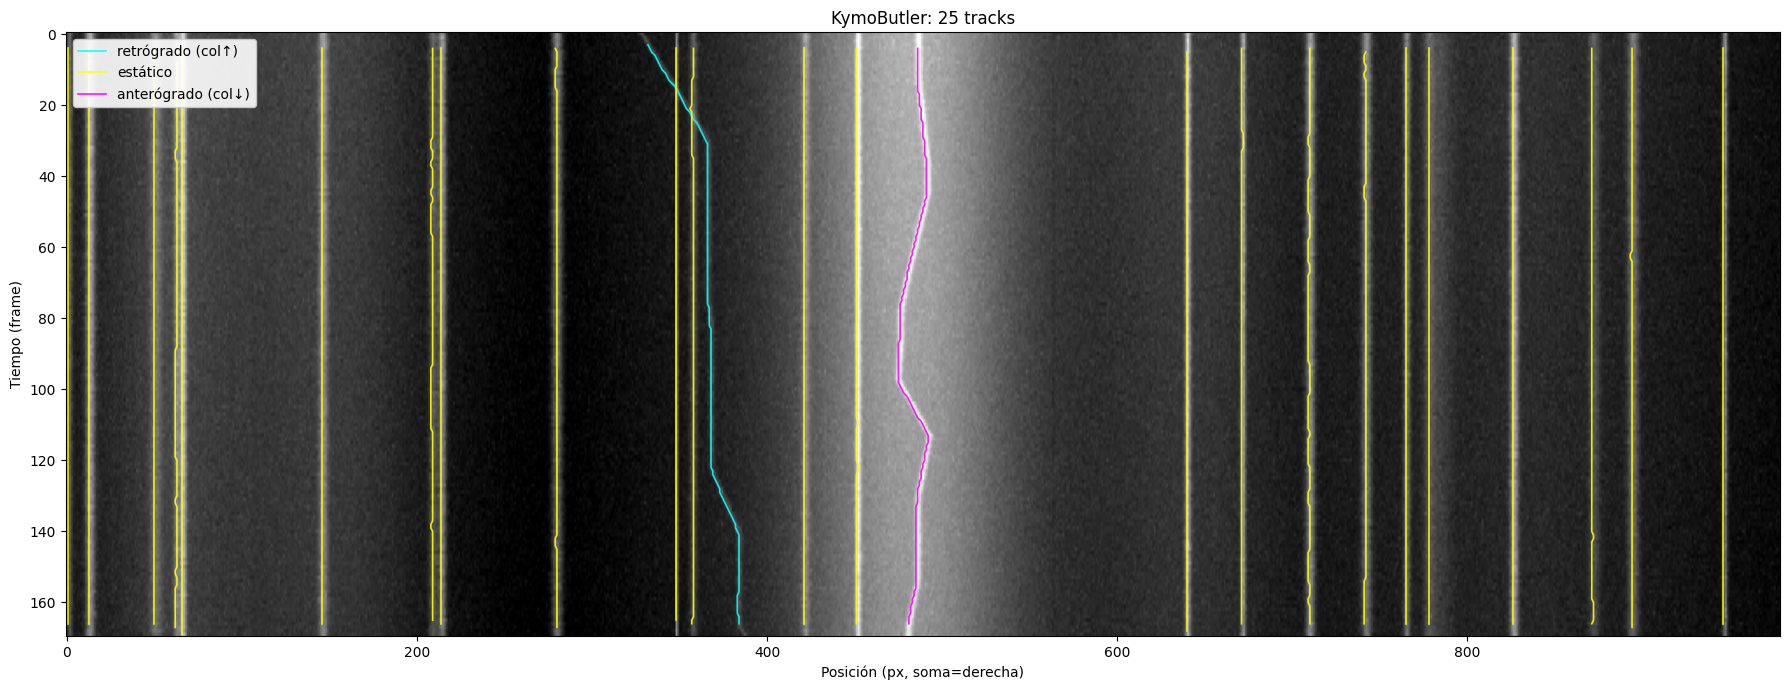

In [9]:
DIR_COLOR = {-1: "magenta", 1: "cyan", 0: "yellow"}
DIR_LABEL = {-1: "anterógrado (col↓)", 1: "retrógrado (col↑)", 0: "estático"}

fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(raw, cmap="gray", aspect="auto")
vistos = set()
for trk in tracks:
    d = direccion_por_desplazamiento(trk.points)
    pts = np.array(trk.points)  # (N, 2) = (frame, col)
    lbl = DIR_LABEL[d] if d not in vistos else None
    vistos.add(d)
    ax.plot(
        pts[:, 1], pts[:, 0], color=DIR_COLOR[d], linewidth=1.2, alpha=0.9, label=lbl
    )
ax.set_title(f"KymoButler: {len(tracks)} tracks")
ax.set_xlabel("Posición (px, soma=derecha)")
ax.set_ylabel("Tiempo (frame)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 7. Conversión del ground truth a coordenadas de quimógrafo

`pos_um` (longitud de arco desde el soma) → columna del quimógrafo con el flip:

```
kymo_col = (kymo_w_native - 1 - pos_um / pixel_scale) * scale_factor
```

Dirección GT en el quimógrafo (flipped, soma=derecha):

- `anterograde` → -1 (columna decreciente con el tiempo)
- `retrograde` → +1 (columna creciente)
- `static` → 0
- `bidirectional` → sin dirección fija, se excluye de la métrica de dirección


In [10]:
pos_vis, tipo_de, gt_ids, gt_dir, gt_col, gt_por_frame = convertir_gt(
    positions, kymo_native_w, PIXEL_SCALE, scale_factor
)

print(f"Partículas GT: {len(gt_ids)} ({dict(Counter(tipo_de.values()))})")
print(f"Filas en GT (visibles): {len(pos_vis)}")
print(
    f"Rango kymo_col en GT: [{pos_vis.kymo_col.min():.1f}, {pos_vis.kymo_col.max():.1f}]"
)
print(f"Rango columnas en KymoButler raw: [0, {raw.shape[1]-1}]")

Partículas GT: 24 ({'static': 22, 'anterograde': 1, 'retrograde': 1})
Filas en GT (visibles): 4080
Rango kymo_col en GT: [1.6, 946.6]
Rango columnas en KymoButler raw: [0, 978]


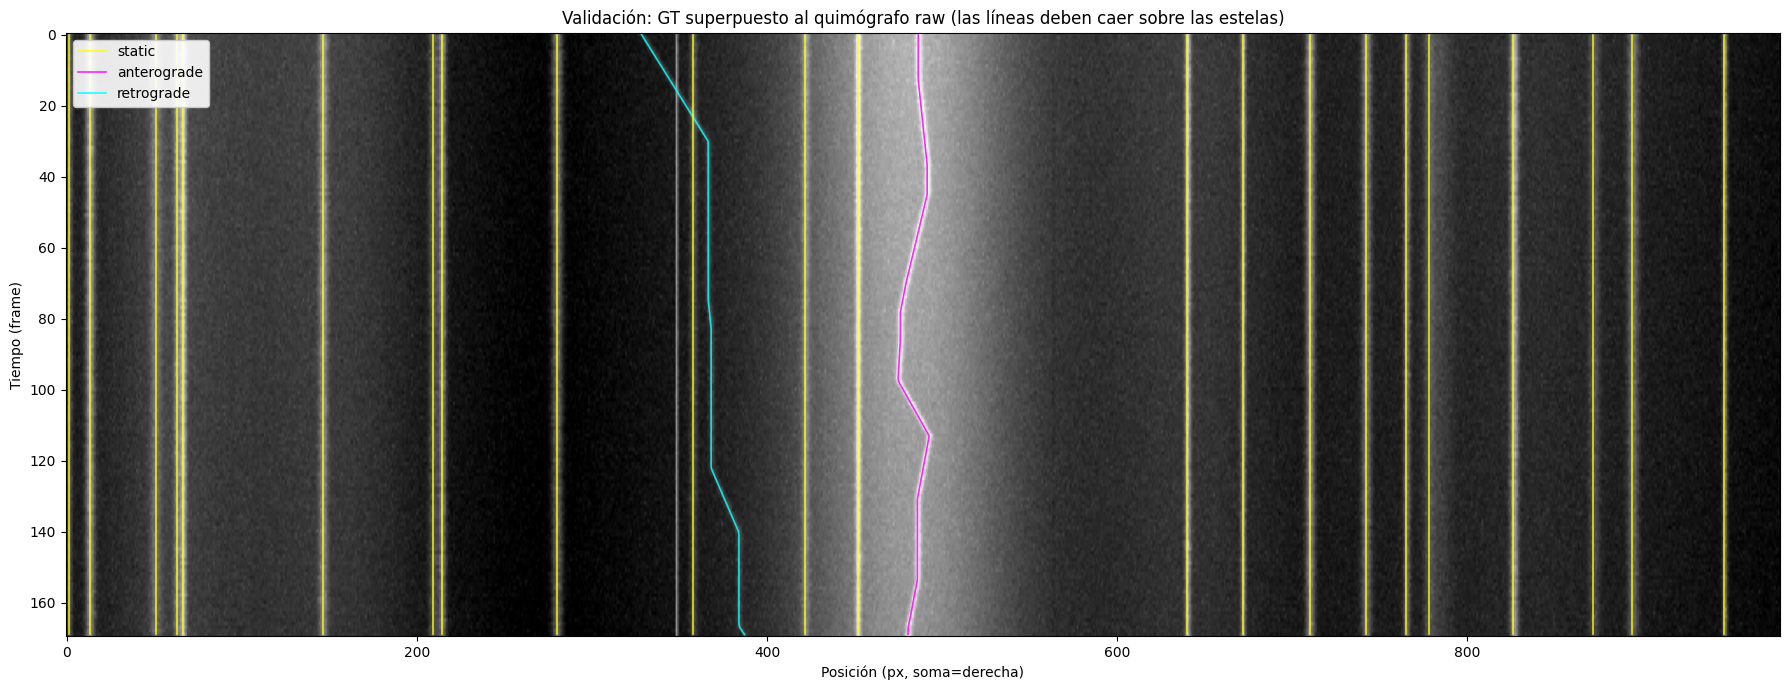

In [11]:
# Overlay de validación: GT sobre el quimógrafo raw.
# Las líneas deben caer sobre las estelas brillantes.
fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(raw, cmap="gray", aspect="auto")

COLORES_GT = {
    "static": "yellow",
    "anterograde": "magenta",
    "retrograde": "cyan",
    "bidirectional": "orange",
}
vistos = set()
for pid, sub in pos_vis.groupby("particle_id"):
    ptype = tipo_de[pid]
    sub_s = sub.sort_values("frame")
    lbl = ptype if ptype not in vistos else None
    vistos.add(ptype)
    ax.plot(
        sub_s["kymo_col"],
        sub_s["frame"],
        color=COLORES_GT.get(ptype, "white"),
        linewidth=1.2,
        alpha=0.85,
        label=lbl,
    )

ax.set_title(
    "Validación: GT superpuesto al quimógrafo raw (las líneas deben caer sobre las estelas)"
)
ax.set_xlabel("Posición (px, soma=derecha)")
ax.set_ylabel("Tiempo (frame)")
ax.legend(loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()

---

## 8. Comparación tracks predichos vs GT


In [12]:
comp = comparar_tracks(
    tracks, gt_por_frame, gt_col, tipo_de, gt_dir, scale_factor, PIXEL_SCALE
)
print(comp.to_string(index=False))

 track  gt_id     gt_tipo  n_puntos  id_switch  dir_pred  dir_gt  dir_ok   err_px   err_um
     0      8  retrograde       164      False         1       1    True 0.327308 0.035022
     1      2      static       163      False         0       0    True 0.560625 0.059987
     2      0      static       163      False         0       0    True 0.352826 0.037752
     3     11      static       163      False         0       0    True 0.810426 0.086716
     4     18      static       166      False         0       0    True 0.453919 0.048569
     5      9      static       163      False         0       0    True 0.431275 0.046146
     6     13      static       162      False         0       0    True 0.453146 0.048487
     7     23      static       163      False         0       0    True 0.355284 0.038015
     8      1      static       164      False         0       0    True 0.129553 0.013862
     9      8  retrograde       162      False         0       1   False 1.897158 0.202996

### Métricas agregadas (esta muestra)


In [13]:
resumen = resumen_metricas(comp, gt_ids, tipo_de, tracks, scale_factor, PIXEL_SCALE)

print("=== DETECCIÓN (recall) ===")
print(
    f"  Global: {resumen['n_recuperadas']}/{resumen['n_gt']} = {100*resumen['recall_global']:.0f}%"
)
for tipo, (rec, total) in resumen["recall_por_tipo"].items():
    print(f"  {tipo:12s}: {rec}/{total}")

print("\n=== POSICIÓN ===")
if not np.isnan(resumen["err_medio_px"]):
    print(
        f"  Error medio  : {resumen['err_medio_px']:.2f} px = {resumen['err_medio_um']:.3f} µm"
    )

print("\n=== DIRECCIÓN ===")
print(
    "  (en quimógrafo flipped: anterograde→-1 col↓, retrograde→+1 col↑; bidirectional excluido)"
)
if resumen["n_dir_evaluados"]:
    print(
        f"  Acierto: {100*resumen['dir_accuracy']:.0f}% ({resumen['n_dir_evaluados']} tracks asociados con dirección definida)"
    )

print("\n=== CRUCES ===")
recuperadas = set(comp[comp.gt_id != -1].gt_id)
frag = Counter(comp[comp.gt_id != -1].gt_id)
n_frag = sum(1 for pid, c in frag.items() if c > 1)
print(
    f"  ID-switches (track sobre >1 GT): {resumen['n_idswitch']}/{resumen['n_tracks']} tracks"
)
print(f"  GTs fragmentados (>1 track):     {n_frag}/{len(recuperadas)} recuperadas")
print(f"  Tracks sin GT (falsos +):         {resumen['n_falsos_positivos']}")

=== DETECCIÓN (recall) ===
  Global: 24/24 = 100%
  static      : 22/22
  anterograde : 1/1
  retrograde  : 1/1

=== POSICIÓN ===
  Error medio  : 0.48 px = 0.051 µm

=== DIRECCIÓN ===
  (en quimógrafo flipped: anterograde→-1 col↓, retrograde→+1 col↑; bidirectional excluido)
  Acierto: 96% (25 tracks asociados con dirección definida)

=== CRUCES ===
  ID-switches (track sobre >1 GT): 0/25 tracks
  GTs fragmentados (>1 track):     1/24 recuperadas
  Tracks sin GT (falsos +):         0


### GT vs predicho superpuestos


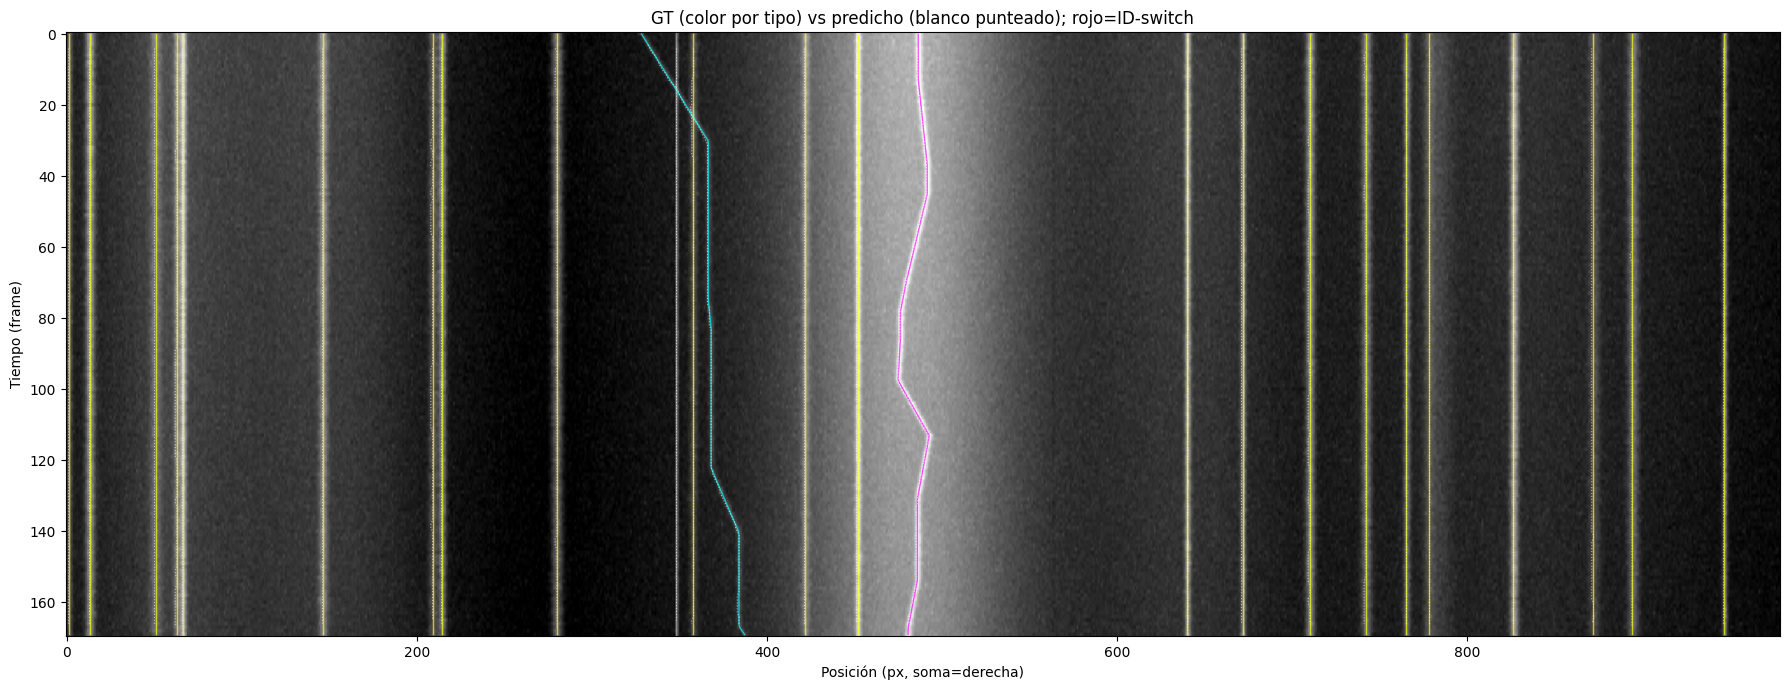

In [14]:
fig, ax = plt.subplots(figsize=(18, 7))
ax.imshow(raw, cmap="gray", aspect="auto")

for pid, sub in pos_vis.groupby("particle_id"):
    sub_s = sub.sort_values("frame")
    ax.plot(
        sub_s["kymo_col"],
        sub_s["frame"],
        color=COLORES_GT.get(tipo_de[pid], "white"),
        linewidth=1.0,
        alpha=0.7,
    )

for k, trk in enumerate(tracks):
    pts = np.array(trk.points)
    ax.plot(
        pts[:, 1], pts[:, 0], color="white", linewidth=0.8, alpha=0.6, linestyle=":"
    )
    if comp.iloc[k]["id_switch"]:
        ax.scatter(pts[:, 1], pts[:, 0], c="red", s=8, marker="x", linewidths=0.8)

ax.set_title("GT (color por tipo) vs predicho (blanco punteado); rojo=ID-switch")
ax.set_xlabel("Posición (px, soma=derecha)")
ax.set_ylabel("Tiempo (frame)")
plt.tight_layout()
plt.show()

---

## 9. (Opcional) Cinética por KymoButler


In [15]:
from kymobutler.postprocessing import postprocess

# pixel_size_time en segundos/frame, pixel_size_space en µm/px -- fps y pixel_scale de esta muestra
stats = postprocess(
    tracks, pixel_size_time=1.0 / FPS, pixel_size_space=PIXEL_SCALE / scale_factor
)
df_cin = pd.DataFrame(stats).rename(
    columns={
        "velocity_um_per_sec": "velocidad_um_s",
        "duration_sec": "duracion_s",
        "distance_um": "distancia_um",
        "start2end_velocity_um_per_sec": "vel_neta_um_s",
    }
)

print("Distribución de dirección (postprocess de KB):")
print(f"  right (+1): {(df_cin.direction == 1).sum()}  ← retrógrado en kymo flipped")
print(f"  left  (-1): {(df_cin.direction == -1).sum()} ← anterógrado en kymo flipped")
print(f"  static( 0): {(df_cin.direction == 0).sum()}")
print()
print(
    df_cin[["direction", "velocidad_um_s", "duracion_s", "distancia_um"]]
    .describe()
    .round(3)
)

Distribución de dirección (postprocess de KB):
  right (+1): 2  ← retrógrado en kymo flipped
  left  (-1): 4 ← anterógrado en kymo flipped
  static( 0): 19

       direction  velocidad_um_s  duracion_s  distancia_um
count     25.000          25.000      25.000        25.000
mean      -0.080           0.183      49.556         0.732
std        0.493           0.015       0.310         1.519
min       -1.000           0.176      48.632         0.000
25%        0.000           0.176      49.544         0.000
50%        0.000           0.176      49.544         0.000
75%        0.000           0.182      49.544         0.535
max        1.000           0.230      50.456         5.778


---

## 10. Evaluación agregada sobre varias muestras del dataset

La muestra de las secciones 4–9 es un solo caso (perfil `wt_n1`, el de menor ruido). Para tener una
idea de cómo se comporta KymoButler en general, corremos el mismo pipeline sobre las primeras
`N_POR_PERFIL` muestras de **cada uno** de los 8 perfiles del split `test` — no las 400 completas,
para que el notebook corra rápido (~0.5s/muestra en CPU); subir `N_POR_PERFIL` para más cobertura.


In [16]:
N_POR_PERFIL = 5  # muestras por perfil a evaluar

filas_agregadas = []
for perfil in PROFILES:
    sub = df_manifest[df_manifest.profile == perfil].iloc[:N_POR_PERFIL]
    for _, fila in sub.iterrows():
        s_dir = SPLIT_DIR / fila["sample_dir"]
        kymo_n, kymo_png_s, pos_s, meta_s, px_scale_s, fps_s = cargar_sample(s_dir)
        was_neg_s, raw_s, pre_s, pred_s, sf_s = segmentar(
            kymo_png_s, kymo_n.shape, models
        )
        tracks_s = trackear(pred_s, pre_s, was_neg_s, models)
        _, tipo_de_s, gt_ids_s, gt_dir_s, gt_col_s, gt_por_frame_s = convertir_gt(
            pos_s, kymo_n.shape[1], px_scale_s, sf_s
        )
        comp_s = comparar_tracks(
            tracks_s, gt_por_frame_s, gt_col_s, tipo_de_s, gt_dir_s, sf_s, px_scale_s
        )
        resumen_s = resumen_metricas(
            comp_s, gt_ids_s, tipo_de_s, tracks_s, sf_s, px_scale_s
        )
        resumen_s["profile"] = perfil
        resumen_s["sample_dir"] = fila["sample_dir"]
        filas_agregadas.append(resumen_s)

df_agregado = pd.DataFrame(filas_agregadas)
print(
    f"{len(df_agregado)} muestras evaluadas ({N_POR_PERFIL} por perfil × {len(PROFILES)} perfiles)."
)

/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]



Building tracks:   0%|          | 0/25 [00:00<?, ?it/s]


Building tracks:  36%|███▌      | 9/25 [00:00<00:00, 86.74it/s]


Building tracks:  76%|███████▌  | 19/25 [00:00<00:00, 92.33it/s]


Building tracks:   0%|          | 0/28 [00:00<?, ?it/s]

...


Building tracks:  24%|██▍       | 10/41 [00:00<00:00, 88.03it/s]


Building tracks:  46%|████▋     | 19/41 [00:00<00:00, 81.92it/s]


Building tracks:  68%|██████▊   | 28/41 [00:00<00:00, 78.49it/s]


Building tracks:  88%|████████▊ | 36/41 [00:00<00:00, 29.13it/s]

40 muestras evaluadas (5 por perfil × 8 perfiles).


### Predicho vs GT, lado a lado (una muestra representativa por perfil)

Mismo color por dirección/tipo que en las secciones 6 y 7. Izquierda = tracks predichos por
KymoButler; derecha = ground truth. Sirve para inspeccionar visualmente dónde falla cada perfil
(p.ej. `lbd_n3`, que tuvo más ID-switches en la tabla agregada) en vez de leerlo solo en números.


/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]



Building tracks:   0%|          | 0/25 [00:00<?, ?it/s]


Building tracks:  36%|███▌      | 9/25 [00:00<00:00, 87.52it/s]


Building tracks:  76%|███████▌  | 19/25 [00:00<00:00, 93.53it/s]

/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]


...

/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]



Building tracks:   0%|          | 0/37 [00:00<?, ?it/s]


Building tracks:  27%|██▋       | 10/37 [00:00<00:00, 92.70it/s]


Building tracks:  54%|█████▍    | 20/37 [00:00<00:00, 84.55it/s]


Building tracks:  84%|████████▍ | 31/37 [00:00<00:00, 56.77it/s]

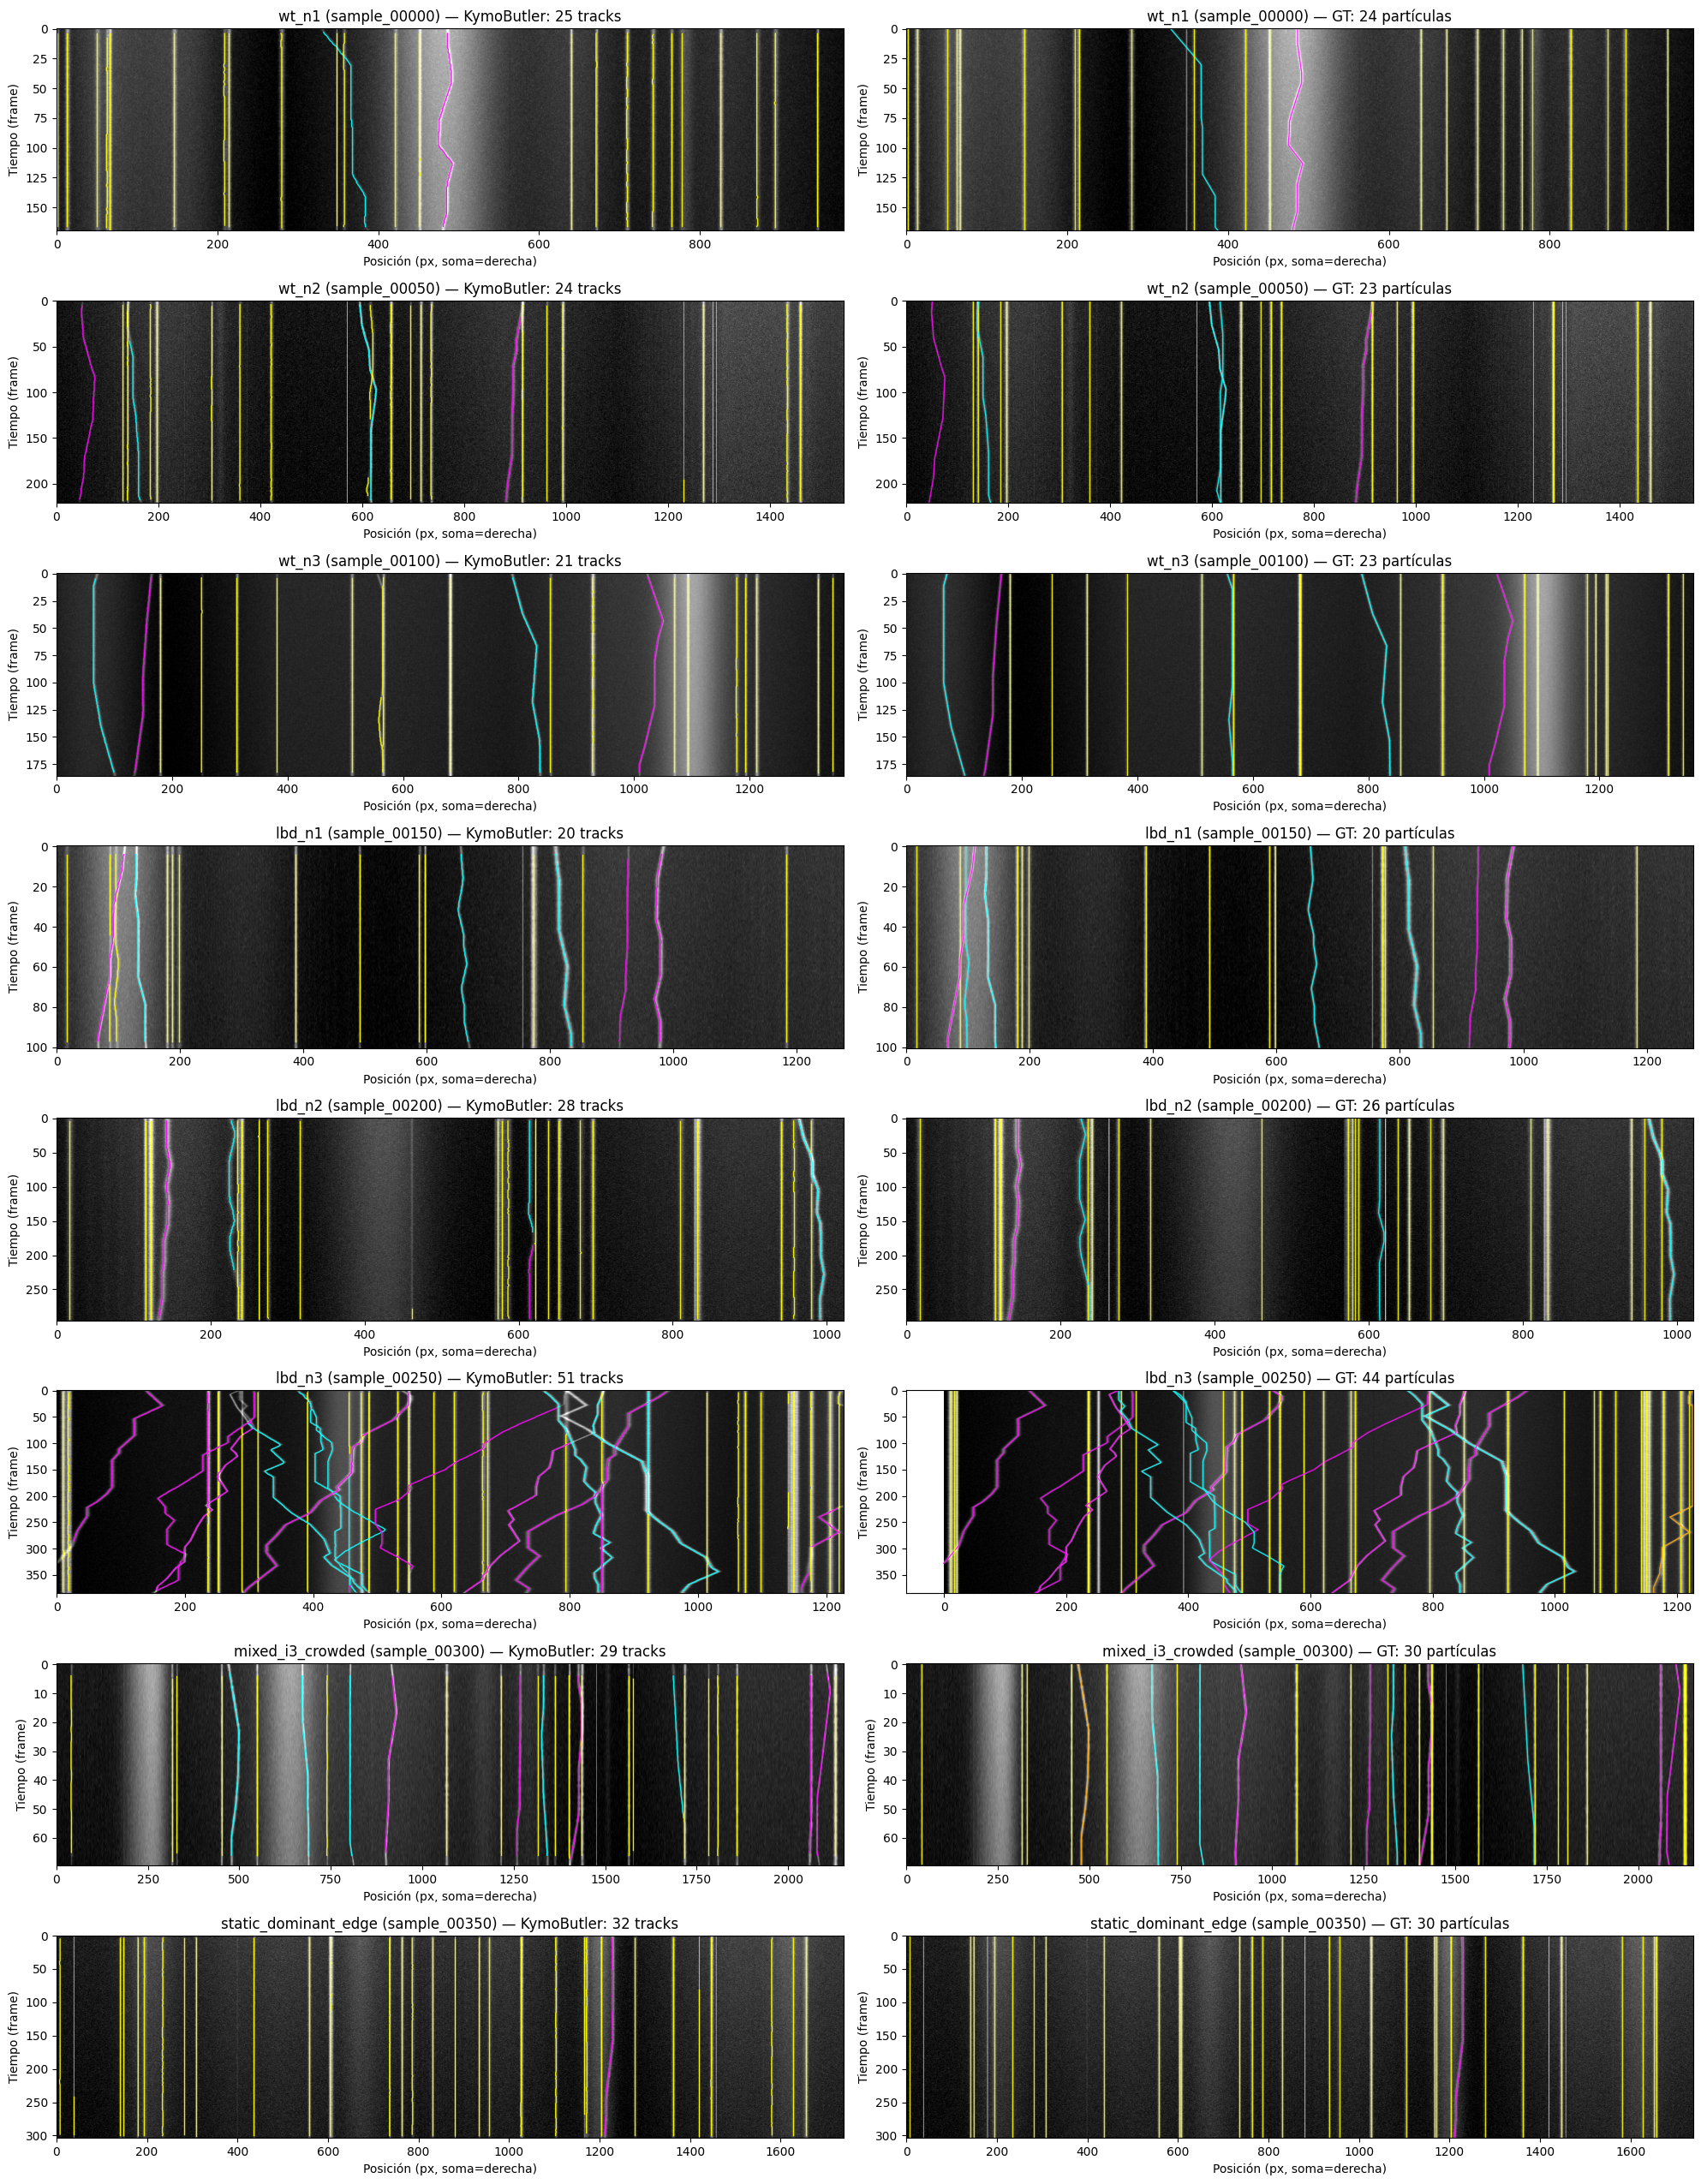

In [17]:
fig, axes = plt.subplots(len(PROFILES), 2, figsize=(20, 3.2 * len(PROFILES)))

for row, perfil in enumerate(PROFILES):
    fila = df_manifest[df_manifest.profile == perfil].iloc[0]
    s_dir = SPLIT_DIR / fila["sample_dir"]
    kymo_n, kymo_png_s, pos_s, meta_s, px_scale_s, fps_s = cargar_sample(s_dir)
    was_neg_s, raw_s, pre_s, pred_s, sf_s = segmentar(kymo_png_s, kymo_n.shape, models)
    tracks_s = trackear(pred_s, pre_s, was_neg_s, models)
    pos_vis_s, tipo_de_s, gt_ids_s, gt_dir_s, gt_col_s, gt_por_frame_s = convertir_gt(
        pos_s, kymo_n.shape[1], px_scale_s, sf_s
    )

    ax_pred, ax_gt = axes[row]

    ax_pred.imshow(raw_s, cmap="gray", aspect="auto")
    for trk in tracks_s:
        d = direccion_por_desplazamiento(trk.points)
        pts = np.array(trk.points)
        ax_pred.plot(pts[:, 1], pts[:, 0], color=DIR_COLOR[d], linewidth=1.0, alpha=0.9)
    ax_pred.set_title(
        f"{perfil} ({fila['sample_dir']}) — KymoButler: {len(tracks_s)} tracks"
    )

    ax_gt.imshow(raw_s, cmap="gray", aspect="auto")
    for pid, sub_gt in pos_vis_s.groupby("particle_id"):
        sub_ord = sub_gt.sort_values("frame")
        ax_gt.plot(
            sub_ord["kymo_col"],
            sub_ord["frame"],
            color=COLORES_GT.get(tipo_de_s[pid], "white"),
            linewidth=1.0,
            alpha=0.85,
        )
    ax_gt.set_title(f"{perfil} ({fila['sample_dir']}) — GT: {len(gt_ids_s)} partículas")

    for ax in (ax_pred, ax_gt):
        ax.set_xlabel("Posición (px, soma=derecha)")
        ax.set_ylabel("Tiempo (frame)")

plt.tight_layout()
plt.show()

In [18]:
resumen_por_perfil = (
    df_agregado.groupby("profile")
    .agg(
        recall_global=("recall_global", "mean"),
        err_medio_um=("err_medio_um", "mean"),
        dir_accuracy=("dir_accuracy", "mean"),
        n_idswitch=("n_idswitch", "sum"),
        n_tracks=("n_tracks", "sum"),
        n_falsos_positivos=("n_falsos_positivos", "sum"),
    )
    .reindex(PROFILES)
    .round(3)
)
print(resumen_por_perfil)

print("\n=== Global (todas las muestras evaluadas) ===")
print(f"  Recall medio        : {100*df_agregado.recall_global.mean():.0f}%")
print(f"  Error medio         : {df_agregado.err_medio_um.mean():.3f} µm")
print(f"  Acierto de dirección: {100*df_agregado.dir_accuracy.mean():.0f}%")
print(
    f"  ID-switches (total) : {int(df_agregado.n_idswitch.sum())} / {int(df_agregado.n_tracks.sum())} tracks"
)
print(f"  Falsos positivos    : {int(df_agregado.n_falsos_positivos.sum())}")

                      recall_global  err_medio_um  dir_accuracy  n_idswitch  \
profile                                                                       
wt_n1                         0.933         0.054         0.973           3   
wt_n2                         0.948         0.054         0.932           3   
wt_n3                         0.922         0.052         0.921           7   
lbd_n1                        0.970         0.055         0.923           4   
lbd_n2                        0.938         0.056         0.951           2   
lbd_n3                        0.927         0.056         0.832          58   
mixed_i3_crowded              0.900         0.045         0.946           8   
static_dominant_edge          0.927         0.056         0.994           4   

                      n_tracks  n_falsos_positivos  
profile                                             
wt_n1                      122                   4  
wt_n2                      135                  18

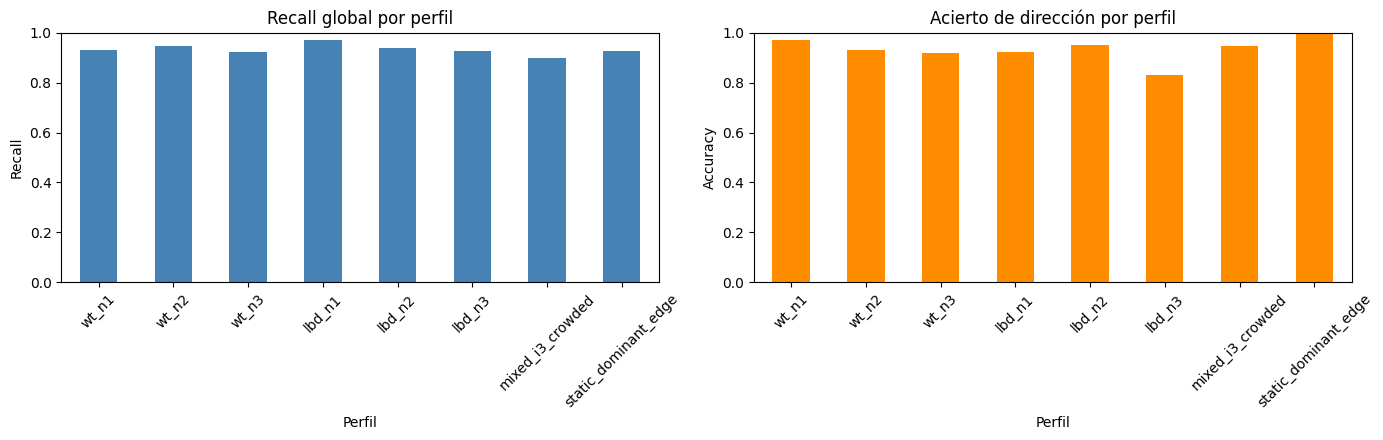

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

resumen_por_perfil["recall_global"].plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Recall global por perfil")
axes[0].set_ylabel("Recall")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=45)

resumen_por_perfil["dir_accuracy"].plot.bar(ax=axes[1], color="darkorange")
axes[1].set_title("Acierto de dirección por perfil")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.set_xlabel("Perfil")
plt.tight_layout()
plt.show()

---

## 11. Muestra `sample_00263` (mismo caso que en NB10 Mask2Former)

`sample_00263` (perfil `lbd_n3`) es una de las muestras seleccionadas dinámicamente en
`10_mask2former_kymografo.ipynb` (sección "seleccion deliberada de muestras", `nlargest(3,
"px_cruce")` sobre el split `test`) por tener uno de los mayores cruces de estelas del split: 13
partículas móviles, AR 1.7:1, 3839 px de columnas compartidas entre trayectorias. Mask2Former
recuperó 3/13 GT (IoU>=0.3) en esa muestra. Corremos acá el mismo pipeline de las secciones 4–9
(reutilizando `cargar_sample`/`segmentar`/`trackear`/`convertir_gt`/`comparar_tracks`/
`resumen_metricas` de la sección 3) sobre esa muestra puntual, para comparar directamente contra
KymoButler.

**Ojo con el criterio de "recuperada"**: no es el mismo entre notebooks. NB10 exige IoU>=0.3 entre
máscara predicha y máscara GT completa (emparejamiento greedy). Acá, `comparar_tracks` asocia cada
track al GT más cercano por mayoría de frames dentro de un radio (`thr_px_nativo=4.0`,
`min_overlap=10` frames) — un track puede contar como "recuperado" con apenas ~10 de los frames
visibles de esa partícula. Los dos números no son estrictamente comparables; por eso además de
recall se reporta una tabla de cobertura (frames emparejados / frames GT visibles) por partícula
móvil.


In [ ]:
from axonal_tracking import (
    etiquetas_deteccion as ed,
)  # sys.path ya tiene ../src (celda 1)

SAMPLE_263 = "sample_00263"
SAMPLE_DIR_263 = SPLIT_DIR / SAMPLE_263

kymo_263, kymo_png_263, positions_263, meta_263, PIXEL_SCALE_263, FPS_263 = (
    cargar_sample(SAMPLE_DIR_263)
)
kymo_263_h, kymo_263_w = kymo_263.shape
print(f"kymo nativo  : {kymo_263_h} × {kymo_263_w} px  (frames × pos_axon)")
print(f"pixel_scale  : {PIXEL_SCALE_263} µm/px")
print(f"fps          : {FPS_263}")

# mismo umbral y criterio de "movil" que usa NB10 (ed.ids_que_se_mueven), para que el
# denominador de recall sea comparable al "13 moviles" de esa muestra en NB10.
ids_mov_263 = ed.ids_que_se_mueven(
    positions_263, PIXEL_SCALE_263, ed.MIN_DESPLAZAMIENTO_PX_MOVIL
)
assert len(ids_mov_263) == 13, (
    f"esperaba 13 moviles (igual que en NB10), obtuve {len(ids_mov_263)} -- el dataset "
    "puede haberse regenerado desde la corrida de NB10, o el umbral difiere."
)
print(f"Particulas moviles (ed.ids_que_se_mueven): {len(ids_mov_263)}")

was_negated_263, raw_263, preprocessed_263, prediction_263, scale_factor_263 = (
    segmentar(kymo_png_263, kymo_263.shape, models)
)
print(
    f"scale_factor = {scale_factor_263:.4f}  "
    f"({'sin redimensionado' if abs(scale_factor_263 - 1) < 0.01 else '⚠ KymoButler redimensionó'})"
)

tracks_263 = trackear(prediction_263, preprocessed_263, was_negated_263, models)
print(f"Tracks detectados: {len(tracks_263)}")

kymo nativo  : 367 × 625 px  (frames × pos_axon)
pixel_scale  : 0.107 µm/px
fps          : 5.18
Particulas moviles (ed.ids_que_se_mueven): 13


scale_factor = 1.0000  (sin redimensionado)


/Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  x = x[pos_axes_slices]



Building tracks:   0%|          | 0/38 [00:00<?, ?it/s]


Building tracks:   5%|▌         | 2/38 [00:00<00:02, 13.99it/s]

...


Building tracks:  63%|██████▎   | 24/38 [00:01<00:00, 18.75it/s]


Building tracks:  74%|███████▎  | 28/38 [00:01<00:00, 23.98it/s]


Building tracks:  82%|████████▏ | 31/38 [00:01<00:00, 23.88it/s]


Building tracks:  89%|████████▉ | 34/38 [00:01<00:00, 25.38it/s]

Tracks detectados: 63


In [ ]:
pos_vis_263, tipo_de_263, gt_ids_263, gt_dir_263, gt_col_263, gt_por_frame_263 = (
    convertir_gt(positions_263, kymo_263_w, PIXEL_SCALE_263, scale_factor_263)
)
print(f"Partículas GT: {len(gt_ids_263)} ({dict(Counter(tipo_de_263.values()))})")

comp_263 = comparar_tracks(
    tracks_263,
    gt_por_frame_263,
    gt_col_263,
    tipo_de_263,
    gt_dir_263,
    scale_factor_263,
    PIXEL_SCALE_263,
)
resumen_263 = resumen_metricas(
    comp_263, gt_ids_263, tipo_de_263, tracks_263, scale_factor_263, PIXEL_SCALE_263
)

# resumen_263 cuenta las 24 particulas visibles (estaticas incluidas). Para comparar
# contra el "3/13 GT recuperadas" de NB10 hay que restringir a las 13 moviles.
recuperadas_263 = set(comp_263[comp_263.gt_id != -1].gt_id)
mov_recuperadas_263 = recuperadas_263 & ids_mov_263

print("=== DETECCIÓN (recall) ===")
print(
    f"  Global (todas, incl. estaticas): {resumen_263['n_recuperadas']}/{resumen_263['n_gt']} = "
    f"{100 * resumen_263['recall_global']:.0f}%"
)
print(
    f"  Moviles (comparable a NB10)     : {len(mov_recuperadas_263)}/{len(ids_mov_263)} = "
    f"{100 * len(mov_recuperadas_263) / len(ids_mov_263):.0f}%"
)
for tipo, (rec, total) in resumen_263["recall_por_tipo"].items():
    print(f"  {tipo:12s}: {rec}/{total}")

print("\n=== POSICIÓN ===")
if not np.isnan(resumen_263["err_medio_px"]):
    print(
        f"  Error medio  : {resumen_263['err_medio_px']:.2f} px = "
        f"{resumen_263['err_medio_um']:.3f} µm"
    )

print("\n=== DIRECCIÓN ===")
if resumen_263["n_dir_evaluados"]:
    print(
        f"  Acierto: {100 * resumen_263['dir_accuracy']:.0f}% "
        f"({resumen_263['n_dir_evaluados']} tracks con dirección definida)"
    )

print("\n=== CRUCES ===")
frag_263 = Counter(comp_263[comp_263.gt_id != -1].gt_id)
n_frag_263 = sum(1 for pid, c in frag_263.items() if c > 1)
print(
    f"  ID-switches (track sobre >1 GT): {resumen_263['n_idswitch']}/"
    f"{resumen_263['n_tracks']} tracks"
)
print(
    f"  GTs fragmentados (>1 track):     {n_frag_263}/{len(recuperadas_263)} recuperadas"
)
print(f"  Tracks sin GT (falsos +):         {resumen_263['n_falsos_positivos']}")

# Cobertura por particula movil emparejada: comparar_tracks marca "recuperada" con un
# minimo de 10 frames en mayoria (min_overlap), un criterio mucho mas laxo que el
# IoU>=0.3 de NB10 -- esta tabla muestra que fraccion real de cada traza movil cubre
# el/los track(s) de KymoButler que le fueron asignados.
thr_px_263 = 4.0 * scale_factor_263


def _gt_mas_cercano_263(t, x):
    mejor, dmin = -1, thr_px_263
    for pid, gx in gt_por_frame_263.get(int(t), []):
        d = abs(x - gx)
        if d <= dmin:
            mejor, dmin = int(pid), d
    return mejor


frames_visibles_263 = (
    positions_263[positions_263.visible == 1].groupby("particle_id").size()
)

filas_cobertura = []
for k, trk in enumerate(tracks_263):
    dominante = int(comp_263.iloc[k]["gt_id"])
    if dominante not in ids_mov_263:
        continue
    n_match = sum(1 for (t, x) in trk.points if _gt_mas_cercano_263(t, x) == dominante)
    n_visible = int(frames_visibles_263.get(dominante, 0))
    filas_cobertura.append(
        {
            "track": k,
            "gt_id": dominante,
            "gt_tipo": tipo_de_263[dominante],
            "frames_track": len(trk.points),
            "frames_emparejados": n_match,
            "frames_gt_visible": n_visible,
            "cobertura": n_match / n_visible if n_visible else np.nan,
        }
    )
df_cobertura_263 = pd.DataFrame(filas_cobertura).sort_values("gt_id")
print(
    "\n=== COBERTURA de las moviles recuperadas (frames emparejados / frames GT visibles) ==="
)
print(df_cobertura_263.to_string(index=False))

Partículas GT: 44 ({'static': 31, 'anterograde': 7, 'retrograde': 5, 'bidirectional': 1})
=== DETECCIÓN (recall) ===
  Global (todas, incl. estaticas): 39/44 = 89%
  Moviles (comparable a NB10)     : 13/13 = 100%
  static      : 26/31
  anterograde : 7/7
  retrograde  : 5/5
  bidirectional: 1/1

=== POSICIÓN ===
  Error medio  : 0.50 px = 0.053 µm

=== DIRECCIÓN ===
  Acierto: 79% (61 tracks con dirección definida)

=== CRUCES ===
  ID-switches (track sobre >1 GT): 18/63 tracks
  GTs fragmentados (>1 track):     17/39 recuperadas
  Tracks sin GT (falsos +):         0

=== COBERTURA de las moviles recuperadas (frames emparejados / frames GT visibles) ===
 track  gt_id       gt_tipo  frames_track  frames_emparejados  frames_gt_visible  cobertura
    49      3   anterograde           118                 111                367   0.302452
    50      3   anterograde            13                  13                367   0.035422
    22      3   anterograde           136                 127 

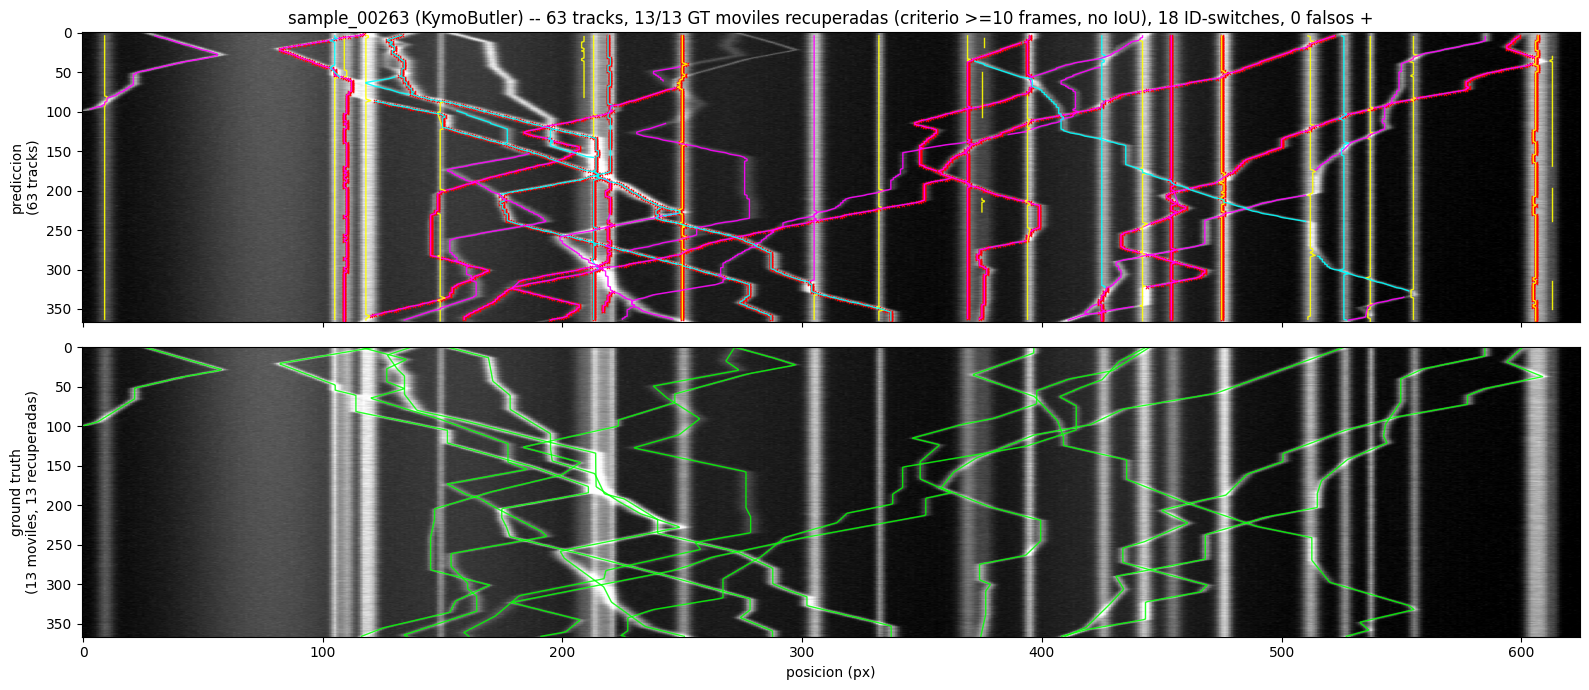

In [22]:
fig, (ax_p, ax_g) = plt.subplots(2, 1, figsize=(16, 7), sharex=True, sharey=True)

ax_p.imshow(raw_263, cmap="gray", aspect="auto")
for k, trk in enumerate(tracks_263):
    d = direccion_por_desplazamiento(trk.points)
    pts = np.array(trk.points)
    ax_p.plot(pts[:, 1], pts[:, 0], color=DIR_COLOR[d], linewidth=1.0, alpha=0.9)
    if comp_263.iloc[k]["id_switch"]:
        ax_p.scatter(pts[:, 1], pts[:, 0], c="red", s=6, marker="x", linewidths=0.7)
ax_p.set_ylabel(f"prediccion\n({len(tracks_263)} tracks)")

ax_g.imshow(raw_263, cmap="gray", aspect="auto")
for pid, sub in pos_vis_263[pos_vis_263.particle_id.isin(ids_mov_263)].groupby(
    "particle_id"
):
    sub_s = sub.sort_values("frame")
    color = "lime" if pid in mov_recuperadas_263 else "white"
    ax_g.plot(sub_s["kymo_col"], sub_s["frame"], color=color, linewidth=1.0, alpha=0.85)
ax_g.set_ylabel(
    f"ground truth\n({len(ids_mov_263)} moviles, {len(mov_recuperadas_263)} recuperadas)"
)

ax_p.set_title(
    f"{SAMPLE_263} (KymoButler) -- {len(tracks_263)} tracks, "
    f"{len(mov_recuperadas_263)}/{len(ids_mov_263)} GT moviles recuperadas "
    f"(criterio >=10 frames, no IoU), {resumen_263['n_idswitch']} ID-switches, "
    f"{resumen_263['n_falsos_positivos']} falsos +"
)
ax_g.set_xlabel("posicion (px)")
plt.tight_layout()
plt.show()

---

## Conclusión

Medimos **KymoButler** sobre el dataset sintético real-scale (`datasets/test/`, calibrado contra
quimógrafos reales del laboratorio — `docs/handover.md`), reemplazando el dataset de juguete que
generaba el notebook 05.

**Convenciones clave** para este pipeline:

- El quimógrafo está **flipped** (soma=derecha): anterógrado → col↓, retrógrado → col↑.
- El GT se convierte con `kymo_col = (W-1 - pos_um/pixel_scale) × scale_factor`.
- `pixel_scale` y `fps` se leen del `config.yaml` de cada muestra, no de una constante global.
- `scale_factor` corrige el posible redimensionado interno de KymoButler.

### Próximos pasos

1. **Cobertura completa**: subir `N_POR_PERFIL` (sección 10) a las 50 muestras por perfil del split
   `test`, o correr sobre `train`/`val` también, para números menos ruidosos.
2. **Comparación directa con detect-then-segment**: `09_segmentacion_transformer.ipynb` evalúa
   YOLO+SAM3 sobre el mismo `datasets/test/` — con `resumen_metricas` ya extraído acá, comparar
   recall/error/ID-switches entre KymoButler y esa arquitectura es directo.
3. **Quimógrafos reales**: aplicar el mismo flujo de métricas a quimógrafos del laboratorio, una
   vez que estén anotados.
